In [1]:
import pandas as pd
df = pd.read_csv("raw_data.csv")

In [2]:
# Transformation on data
df2 = df.copy()
df2["salary"] = df2["salary"].fillna(0)
df2.loc[6,"salary"] = 40000
df2["salary"] = df2["salary"].astype("float64")

# apply()
# adding new column and tax if the salary above 50k

df2["tax"] = df2["salary"].apply(lambda x : "20%" if x >= 50000 else "10%")
df2

# map()
department_map = {"Sales":"S","HR":"H","IT":"I","Finance":"F"}
df2["department"] = df2["department"].map(department_map)
df2

# assing()
df2 = df2.assign(new_salary_with_30_percent_hike = df2["salary"] * 1.3)

# replace()
df2["name"] = df2["name"].replace("John Doe","Kashi")
df2

# Rename
df2.columns = ["Id","Name","Age","Department","Salary","Joining_Date","Email","Tax","New_Salary_With_30_Percent_Hike"]
df2 = df2.rename(columns={"New_Salary_With_30_Percent_Hike":"New_Salary"})
df2 = df2.rename(index={1:"First"})
df2

# Sort
df2["Salary"].sort_values()
df2 = df2.sort_values(by="Salary", ascending=False)

#reset
df2 = df2.reset_index()
df2 = df2.reset_index(drop = True)

# ranking
df2["Ranking"] = df2["Salary"].rank()
df2["Ranking"] = df2["Salary"].rank(method = "dense") # to resolve tia same vale
df2["Ranking"] = df2["Salary"].rank(method = "min")
df2["Ranking"] = df2["Salary"].rank(method = "max")
df2

# re-ordring colunms named
df2 = df2[["Id","Name","Age","Department","Salary","Joining_Date","Email","New_Salary" ,"Tax",]]
df2


,Id,Name,Age,Department,Salary,Joining_Date,Email,New_Salary,Tax
0,15,Amit Sharma,35.0,F,67000.0,2021-07-25,amit.sharma@email,87100.0,20%
1,12,Tom Clark,45.0,F,65000.0,2020-02-29,tom.clark@email.com,84500.0,20%
2,14,Raj Mehta,NaN,I,62000.0,2021-06-18,raj.mehta@email.com,80600.0,20%
3,8,Anna Kim,31.0,F,61000.0,2022-13-01,anna.kim@email.com,79300.0,20%
4,3,Mike Johnson,30.0,I,60000.0,2022-01-15,mike.j@email,78000.0,20%
5,10,Mark Taylor,27.0,I,58000.0,2021-09-31,mark.taylor@email.com,75400.0,20%
6,13,Nina Patel,29.0,S,53000.0,2021-04-12,nina.patel@email.com,68900.0,20%
7,5,Chris Brown,28.0,S,52000.0,15-08-2021,chris.brown@email.com,67600.0,20%
8,1,Kashi,29.0,S,50000.0,2021-05-10,john.doe@email.com,65000.0,20%
9,9,Kashi,29.0,S,50000.0,2021-05-10,john.doe@email.com,65000.0,20%


In [19]:
df2 = df.copy()
new_col_order = [col for col in df2.columns if col != "id"] + ["id"]
df2[new_col_order]

,name,age,department,salary,joining_date,email,id
0,John Doe,29.0,Sales,50000,2021-05-10,john.doe@email.com,1
1,Jane Smith,NaN,HR,45000,10/06/2020,jane.smith@email.com,2
2,Mike Johnson,30.0,IT,60000,2022-01-15,mike.j@email,3
3,Emily Davis,34.0,Finance,NaN,2021/07/20,emily.davis@email.com,4
4,Chris Brown,28.0,Sales,52000,15-08-2021,chris.brown@email.com,5
5,Sarah Wilson,NaN,HR,48000,2020-11-30,sarah.wilson@email.com,6
6,David Lee,42.0,IT,not_available,2019-03-25,david.lee@email.com,7
7,Anna Kim,31.0,Finance,61000,2022-13-01,anna.kim@email.com,8
8,John Doe,29.0,Sales,50000,2021-05-10,john.doe@email.com,9
9,Mark Taylor,27.0,IT,58000,2021-09-31,mark.taylor@email.com,10


In [33]:
# how to write to csv
# to_csv()
df2["age"] = df2["age"].fillna(25)
df2 = df2.drop_duplicates()

df2.to_csv("new_updated_data")

In [22]:
# Groupby and aggregation

df2.groupby("Department")["Salary"].mean()
df2.groupby("Department")["Salary"].max()
df2.groupby("Department")["Salary"].min()

# agg for multiple operation in one 
df2.groupby("Department")["Salary"].agg(["mean","max","min"])
df2.groupby("Department")["Salary"].agg(mean_value="mean",max_value="max",min_value="min")

df2.groupby("Department").agg({
    "Age":"max",
    "Salary":"mean"
})

df2.groupby("Department").agg(
    max_age = ("Age" ,"max"),
    mean_salary = ("Salary","mean")
)

,max_age,mean_salary
Department,,
F,45.0,48250.000000
H,33.0,46666.666667
I,42.0,55000.000000
S,29.0,51250.000000


<Axes: xlabel='Age', ylabel='Salary'>

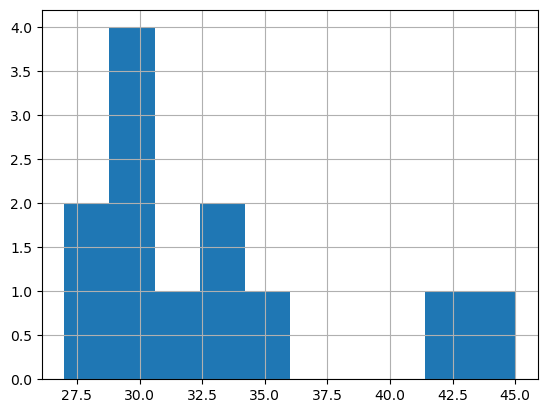

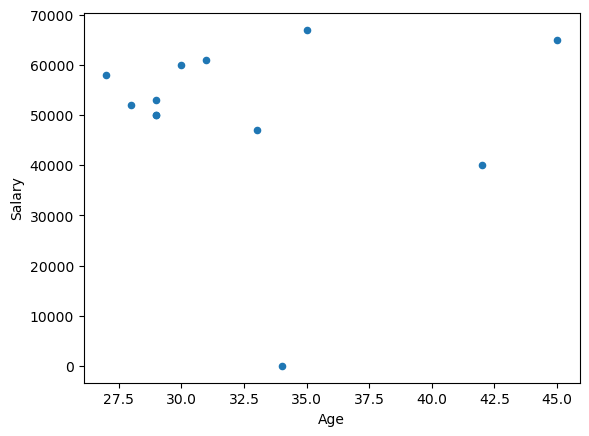

In [37]:
# Basic data visulalisation 

df2["Age"].hist()
df2.plot(kind="scatter",x="Age",y="Salary")

In [50]:
# mearging and join

# Customer DataFrame
customer_df = pd.DataFrame({
    "id": [1, 2, 3, 4, 5],
    "name": ["Rahul", "Rohit", "Saipan", "Sumeet", "Virat"]
})

# Order DataFrame
order_df = pd.DataFrame({
    "order_id": [101, 102, 103, 104, 105,106],
    "id": [1, 2, 4, 5, 1,6],
    "amount": [201, 205, 206, 204, 456, 589]
})

pd.merge(customer_df,order_df,on="id") # inner join
pd.merge(customer_df,order_df,on="id",how="left") # left join
pd.merge(customer_df,order_df,on="id",how="right") # rith join
pd.merge(customer_df,order_df,on="id",how="outer") # outer join

,id,name,order_id,amount
0,1,Rahul,101.0,201.0
1,1,Rahul,105.0,456.0
2,2,Rohit,102.0,205.0
3,3,Saipan,NaN,NaN
4,4,Sumeet,103.0,206.0
5,5,Virat,104.0,204.0
6,6,NaN,106.0,589.0


In [57]:
# data concatination
pd.concat([customer_df,order_df]) # row
pd.concat([customer_df,order_df],ignore_index=True) 
pd.concat([customer_df,order_df],axis=1) 

,id,name,order_id,id,amount
0,1.0,Rahul,101,1,201
1,2.0,Rohit,102,2,205
2,3.0,Saipan,103,4,206
3,4.0,Sumeet,104,5,204
4,5.0,Virat,105,1,456
5,NaN,NaN,106,6,589
